> **Traçabilité (fusion Codes_finaux) :** notebook fusionné à partir de `Codes prof/MNIST_1_DNN_Keras.ipynb` (base) et `Colab_Notebooks/MNIST_1_DNN_Keras.ipynb` (version Colab quasi identique). Les commentaires pédagogiques supplémentaires et cellules ajoutées côté Colab sont conservés et marqués `# [Colab]` ci-dessous.

---
# DNN : `MNIST` (avec `Keras`)
---

## Packages

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from keras import callbacks, layers, models
from keras.datasets import mnist

---
## 1. Données
---

### 1.1. Importation

In [ ]:
test_portion  = 1/5

# [Colab] identification des échantillons train+validation et test
# [Colab] dans tain_valid : on a les données qui vont servir à la constrution du modèle (seront sépar en ech d'apprentissage et de validation)
(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=test_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.2. Graphiques

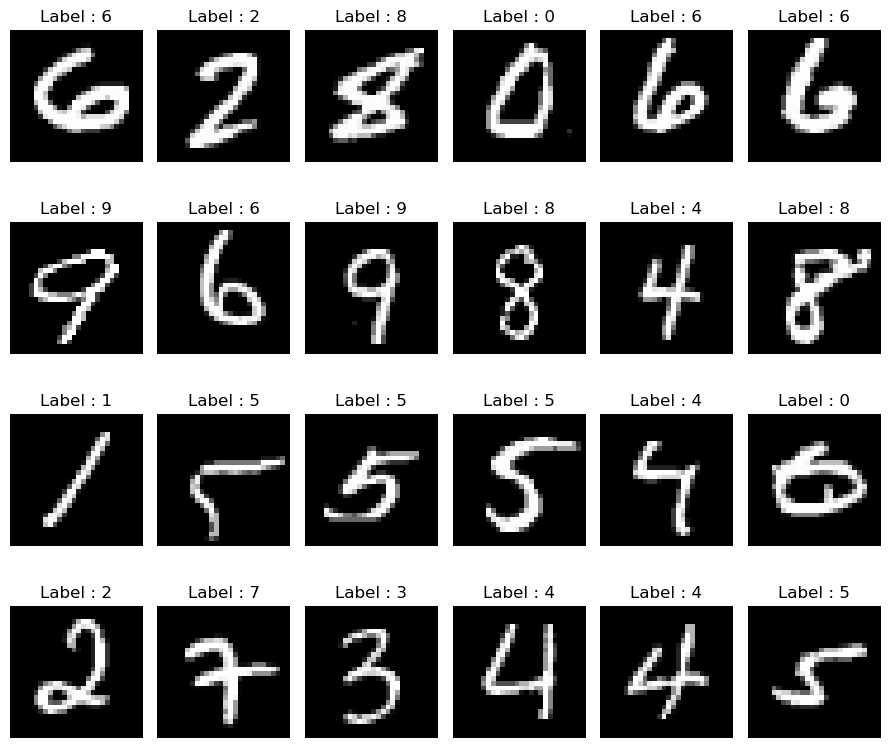

In [3]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Normalisation

In [4]:
X_train_norm = X_train / 255
X_valid_norm = X_valid / 255
X_test_norm  = X_test  / 255

---
## 2. DNN
---

### 2.1. Architecture

In [5]:
dim_inputs  = (28, 28, 1)
dim_outputs = 10

n_units_hl1 = 100
n_units_hl2 = 100

dropout_hl1 = 0.2
dropout_hl2 = 0.2

model = models.Sequential(name='DNN')

model.add(layers.Input(shape=dim_inputs, name='Inputs'))

model.add(layers.Flatten(name='Flatten'))

model.add(layers.Dense(units=n_units_hl1, activation='relu', name='Hidden_layer_1'))
model.add(layers.Dropout(rate=dropout_hl1, name='Dropout_Hidden_layer_1'))

model.add(layers.Dense(units=n_units_hl2, activation='relu', name='Hidden_layer_2'))
model.add(layers.Dropout(rate=dropout_hl2, name='Dropout_Hidden_layer_2'))

model.add(layers.Dense(units=dim_outputs, activation='softmax', name='Output_layer'))

model.summary()

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_1 (Dense)          │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Hidden_layer_1          │ (None, 100)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_2 (Dense)          │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Hidden_layer_2          │ (None, 100)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2. Optimiseur

In [6]:
model.compile(optimizer = 'adam',
              loss      = 'sparse_categorical_crossentropy',
              metrics   = ['accuracy'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 5,
                                   restore_best_weights = True)

### 2.3. Entraînement

In [7]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 300,
                 epochs          = 50,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6550 - loss: 1.1178 - val_accuracy: 0.9355 - val_loss: 0.2259
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9176 - loss: 0.2824 - val_accuracy: 0.9530 - val_loss: 0.1614
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9361 - loss: 0.2120 - val_accuracy: 0.9597 - val_loss: 0.1341
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9479 - loss: 0.1717 - val_accuracy: 0.9652 - val_loss: 0.1181
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9554 - loss: 0.1474 - val_accuracy: 0.9672 - val_loss: 0.1083
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9609 - loss: 0.1325 - val_accuracy: 0.9710 - val_loss: 0.0975
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9645 - loss: 0.1182 - val_accuracy: 0.9724 - val_loss: 0.0911
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9673 - loss: 0.1043 - val_accuracy: 0.

### 2.4. Prévisions

In [8]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 292us/step


array([[6.6477469e-08, 1.1438251e-06, 1.1707385e-05, 5.1261804e-06,
        4.5567821e-09, 6.7200722e-07, 4.3001278e-09, 9.9997586e-01,
        3.2015353e-07, 5.1922975e-06],
       [2.5410208e-07, 1.7176438e-04, 9.9978632e-01, 4.1606047e-05,
        1.4544338e-11, 5.5155329e-09, 7.7100161e-08, 5.8385979e-10,
        5.4780416e-09, 5.2460602e-13],
       [1.7134049e-07, 9.9991757e-01, 5.2229743e-06, 2.5561023e-06,
        3.0421688e-05, 2.8837113e-07, 4.0181662e-06, 3.4356432e-05,
        4.7515423e-06, 7.3355255e-07],
       [9.9996144e-01, 1.7370824e-07, 4.8313459e-06, 5.3764309e-09,
        1.5080760e-08, 3.1961170e-07, 3.2036700e-05, 1.0867739e-07,
        1.7787416e-08, 1.1758121e-06],
       [3.4055594e-07, 3.6309046e-07, 5.0662129e-07, 5.6385868e-08,
        9.9963045e-01, 1.7013805e-06, 5.5765719e-07, 3.7183352e-05,
        1.3949590e-06, 3.2749338e-04]], dtype=float32)

In [ ]:
# [Colab] optionnel : on checke les Y initiaux
y_test[0:5]

In [9]:
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_pred_classes[0:5]

array([7, 2, 1, 0, 4])

In [10]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.0767
Exactitude test : 0.9780
